# OU - 2D BolbLine__beta sigma are const.

# Dataset and parameter setting
* $\beta=10.0$
* $\sigma=5.0$
* $T=10.0$
* Line: $y=0.4x-5+Noise,\,\, x\sim Uni[-6,6],\,\,Noise\sim N(0.2,1)$, noise待確認
* Bolb: $\mu=(-5,0),\,\,C=I$

# Forward

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 1. 定義你提供的數據生成函數
def sample_line(n_points):
    slope = 0.4
    intercept = -5.0
    x = np.random.uniform(-6, 6, size=n_points)
    noise = np.random.randn(n_points) * 0.2   
    y = slope * x + intercept + noise
    return np.stack([x, y], axis=1)

def sample_blob(n_points):
    mu = np.array([-5, 0])
    C = np.eye(2) * 1.0
    return mu + np.random.multivariate_normal([0,0], C, size=n_points)

def sample_p0_mix(n_blob=3000, n_line=2000):
    blob = sample_blob(n_blob)
    line = sample_line(n_line)
    data = np.concatenate([blob, line], axis=0)
    np.random.shuffle(data)
    return data


In [2]:
# 2. 設定 OU 參數
beta = 10.0
sigma = 5.0
t = 5  # 演化時間 (設短一點可以看到過渡狀態)

# 生成初始淡藍色數據
x0 = sample_p0_mix(n_blob=1500, n_line=1000)

# 3. 根據 OU 公式計算演化後的橘色數據
# 均值項 (Mean Reversion)
mu_t = np.exp(-beta * t) * x0
# 方差項 (Diffusion)
var_t = (sigma**2 / (2 * beta)) * (1 - np.exp(-2 * beta * t))
std_t = np.sqrt(var_t)
# 加上雜訊
xt = mu_t + std_t * np.random.randn(*x0.shape)


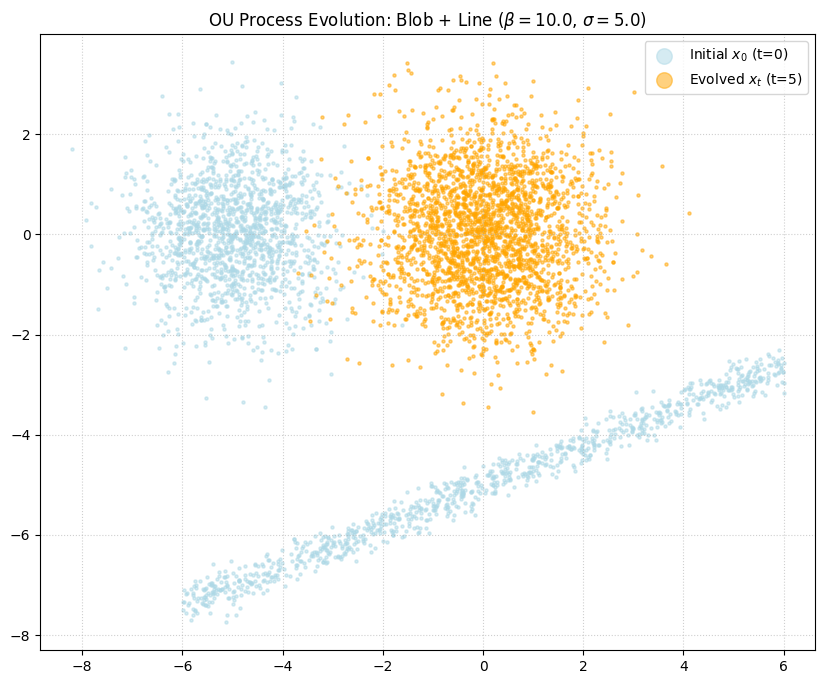

In [3]:
# 4. 繪圖
plt.figure(figsize=(10, 8))
plt.scatter(x0[:, 0], x0[:, 1], color='lightblue', s=5, alpha=0.5, label='Initial $x_0$ (t=0)')
plt.scatter(xt[:, 0], xt[:, 1], color='orange', s=5, alpha=0.5, label=f'Evolved $x_t$ (t={t})')

plt.title(fr'OU Process Evolution: Blob + Line ($\beta={beta}$, $\sigma={sigma}$)')
plt.legend(markerscale=5)
plt.axis('equal')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

# Reverse
根據 Anderson (1982)，對應於你圖片中正向 SDE 的逆向方程為：$$dx_t = [-\beta x_t - \sigma^2 \nabla \log p_t(x_t)] dt + \sigma d\bar{W}_t$$

實作步驟：
1. 收集數據： 使用你之前的 sample_p0_mix 生成大量成對的 $(x_0, x_t)$。
2. 訓練模型： 建立一個簡單的 MLP（例如 3 層全連接層），輸入是 $(x_t, t)$，輸出是預測的雜訊 $\epsilon$ 或 Score $\nabla \log p_t(x_t)$。Loss Function: $\min_{\theta} \mathbb{E} \| \epsilon_\theta(x_t, t) - \epsilon \|^2$
3. 逆向採樣： 從 $x_{10} \sim \mathcal{N}(0, 1.25)$ 開始，利用訓練好的模型一步步走回 $t=0$。

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim

class ScoreNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(3, 256), 
            nn.SiLU(), # 換成 SiLU
            nn.Linear(256, 256),
            nn.SiLU(),
            nn.Linear(256, 256),
            nn.SiLU(),
            nn.Linear(256, 2)
        )

    def forward(self, x, t):
        # 將 t 擴張到與 x 相同的維度並拼接
        t_input = t.view(-1, 1).expand(x.shape[0], 1)
        return self.net(torch.cat([x, t_input], dim=-1))

In [5]:
def train(model, beta, sigma, T, steps):
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    
    for i in range(steps):
        # 1. 採樣原始數據 x0
        x0_np = sample_p0_mix(n_blob=64, n_line=64)
        x0 = torch.tensor(x0_np, dtype=torch.float32)
        
        # 2. 隨機採樣時間 t
        t = torch.rand(x0.shape[0]) * T
        
        # 3. 計算 OU 參數 (根據你圖片的公式)
        mu_t = torch.exp(-beta * t).view(-1, 1) * x0
        std_t = torch.sqrt((sigma**2 / (2*beta)) * (1 - torch.exp(-2*beta*t))).view(-1, 1)
        
        # 4. 加噪
        eps = torch.randn_like(x0)
        xt = mu_t + std_t * eps
        
        # 5. 訓練模型預測 eps
        optimizer.zero_grad()
        eps_pred = model(xt, t)
        loss = nn.MSELoss()(eps_pred, eps)
        loss.backward()
        optimizer.step()
        
        if i % 500 == 0:
            print(f"Step {i}, Loss: {loss.item():.4f}")

In [6]:
@torch.no_grad()
def reverse_sample(model, n_samples, beta, sigma, T, dt):
    device = next(model.parameters()).device
    # 1. 根據圖片公式，T 時刻的穩定狀態方差
    var_T = sigma**2 / (2 * beta)
    x = torch.randn(n_samples, 2).to(device) * np.sqrt(var_T)
    
    # 2. 時間逆向迭代
    ts = np.arange(T, 0, -dt)
    for t_val in ts:
        t_tensor = torch.full((n_samples,), t_val).to(device)
        
        # 預測雜訊
        eps_pred = model(x, t_tensor)
        
        # 根據圖片公式計算當下的 sigma_t
        sigma_t = torch.sqrt((sigma**2 / (2 * beta)) * (1 - torch.exp(torch.tensor(-2 * beta * t_val))))
        
        # 轉換成 Score
        score = -eps_pred / (sigma_t + 1e-5)
        
        # --- Reverse SDE  ---
        # 正向 f(x,t) = -beta * x, g(t) = sigma
        # 逆向 dx = [f - g^2 * score] * dt + g * dW
        # 注意：我們是在往回走，所以這裡的 dt 對應更新方向
        
        drift = -beta * x - (sigma**2) * score
        
        # 隨機項 (Langevin 項)
        noise = torch.randn_like(x) if t_val > dt else 0
        
        # 更新 x
        x = x - drift * dt + sigma * np.sqrt(dt) * noise
        
    return x

開始訓練 Score Model...
Step 0, Loss: 0.8323
Step 500, Loss: 0.0167
Step 1000, Loss: 0.0368
Step 1500, Loss: 0.0160
Step 2000, Loss: 0.0137
訓練完成，正在從雜訊還原數據...


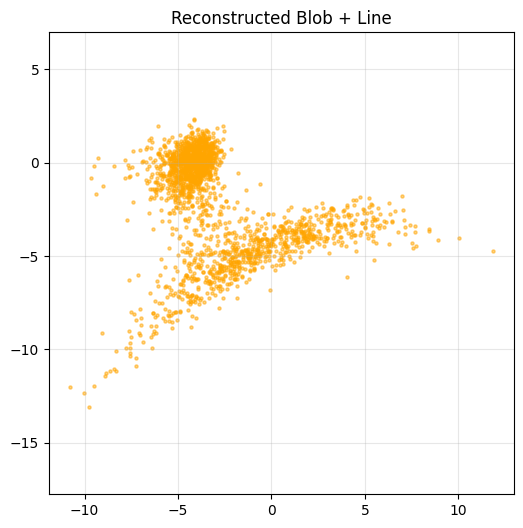

In [7]:
# --- 1. 初始化模型 ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ScoreNet().to(device)

# --- 2. 啟動訓練 (你定義好的 train 函數) ---
# 這裡會跑 5000 次迭代，每 500 步印一次 Loss
print("開始訓練 Score Model...")
T=5
steps=2500
train(model, beta=10.0, sigma=5.0, T=T, steps=steps)

# --- ---
print("訓練完成，正在從雜訊還原數據...")
# 這裡會從 T=10 的高斯雜訊走回 T=0
dt=T/steps
generated_data = reverse_sample(model, n_samples=2000, beta=10.0, sigma=5.0, T=T, dt=dt)

# --- 4. 繪圖驗證 ---
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))
# 轉換回 numpy 繪圖
samples = generated_data.cpu().numpy()
plt.scatter(samples[:, 0], samples[:, 1], alpha=0.5, s=5, color='orange')
plt.title("Reconstructed Blob + Line")
plt.axis('equal')
plt.grid(True, alpha=0.3)
plt.show()

0305.11:27  
觀察: 不知道為甚麼圖形直線會彎曲  
感覺可以放大dt=0.01之類的(但可能某個參數要改之類的)  
  
0308.21:35  
要以T=10, steps=5000來算dt=0.002  
沒調好所以圖才會歪歪的  


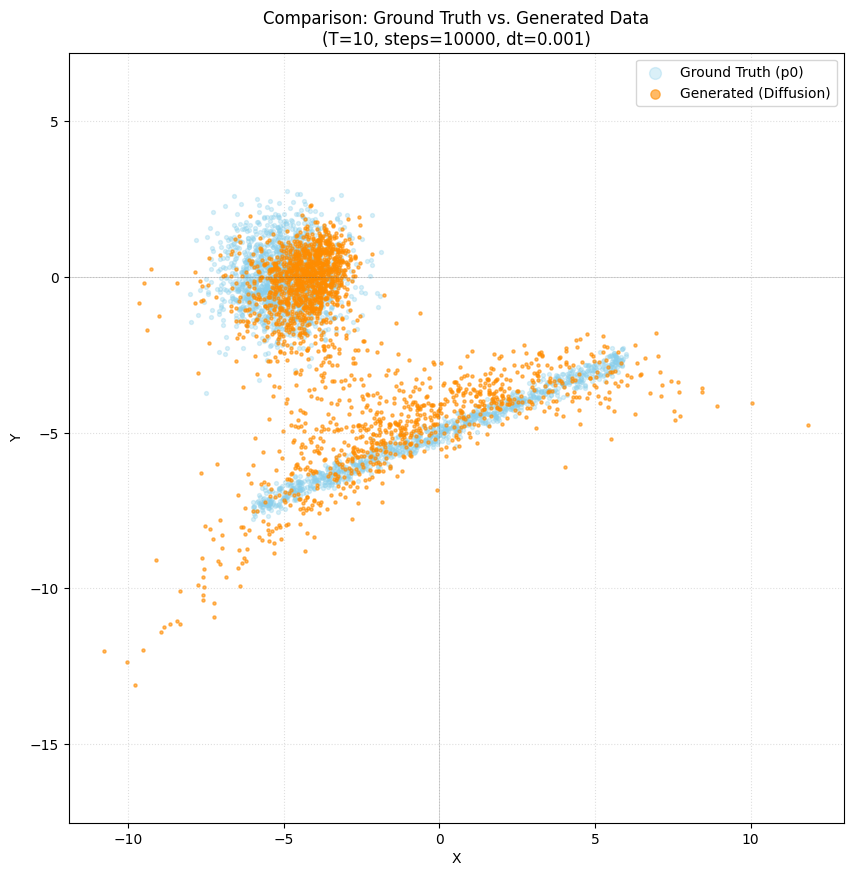

In [8]:
# 1. 準備 Ground Truth 數據 (使用你之前的 sample 函數)
gt_data = sample_p0_mix(n_blob=1500, n_line=1000)
if isinstance(gt_data, torch.Tensor):
    gt_data = gt_data.cpu().numpy()

# 2. 準備 Generated 數據 (從你的 reverse_sample 得到)
gen_data = generated_data.cpu().numpy()

# 3. 繪圖
plt.figure(figsize=(10, 10))

# 繪製 Ground Truth (設定為淡藍色或灰色作為背景基準)
plt.scatter(gt_data[:, 0], gt_data[:, 1], 
            color='skyblue', s=8, alpha=0.3, label='Ground Truth (p0)')

# 繪製 Generated Data (設定為鮮豔的橘色觀察還原效果)
plt.scatter(gen_data[:, 0], gen_data[:, 1], 
            color='darkorange', s=5, alpha=0.6, label='Generated (Diffusion)')

# 輔助標記
plt.axhline(0, color='black', lw=0.5, alpha=0.2)
plt.axvline(0, color='black', lw=0.5, alpha=0.2)
T=10             ##########><<<<<<<<<<<<<<
steps=10000
plt.title(f"Comparison: Ground Truth vs. Generated Data\n(T={T}, steps={steps}, dt={T/steps:.3f})")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend(markerscale=3)
plt.axis('equal') # 確保 X, Y 軸比例一致，才不會看歪
plt.grid(True, linestyle=':', alpha=0.4)

plt.show()